In [15]:
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Глава 1

## 1.1 Импорт библиотек

In [16]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1.2 Загрузка БД

In [17]:
df_mono = pd.read_excel("../data/БД_с_моно_full.xlsx")
df_nomono = pd.read_excel("../data/БД_без_моно_full.xlsx")
df_D = pd.read_excel("../data/Показатель_D.xlsx")
df_F = pd.read_excel("../data/Показатель_F.xlsx")

## 1.3 EDA 

Вывод общей информации датафреймов:

In [18]:
print("БД С МОНО:")
print(f"Размерность: {df_mono.shape}")
print("Информация о БД:")
df_mono.info()
d_mono = df_mono.isna().sum()
print(f"Пропуски:\n{d_mono[d_mono > 0]}")



БД С МОНО:
Размерность: (2484, 8)
Информация о БД:
<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   CaseID   2356 non-null   float64       
 1   Gender   2484 non-null   str           
 2   Age      2484 non-null   int64         
 3   Start    2484 non-null   datetime64[us]
 4   End      2484 non-null   datetime64[us]
 5   Ther     2484 non-null   str           
 6   Outcome  2484 non-null   str           
 7   Vacin    2358 non-null   str           
dtypes: datetime64[us](2), float64(1), int64(1), str(4)
memory usage: 155.4 KB
Пропуски:
CaseID    128
Vacin     126
dtype: int64


In [19]:
print("БД БЕЗ МОНО:")
print(f"Размерность: {df_nomono.shape}")
print("Информация о БД:")
df_nomono.info()
d_nomono = df_nomono.isna().sum()
print(f"Пропуски:\n{d_nomono[d_nomono > 0]}")

БД БЕЗ МОНО:
Размерность: (6262, 8)
Информация о БД:
<class 'pandas.DataFrame'>
RangeIndex: 6262 entries, 0 to 6261
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   CaseID   5602 non-null   float64       
 1   Start    6262 non-null   datetime64[us]
 2   End      6262 non-null   datetime64[us]
 3   Gender   6262 non-null   str           
 4   Age      6262 non-null   int64         
 5   Ther     6262 non-null   str           
 6   Outcome  6262 non-null   str           
 7   Vac      5649 non-null   str           
dtypes: datetime64[us](2), float64(1), int64(1), str(4)
memory usage: 391.5 KB
Пропуски:
CaseID    660
Vac       613
dtype: int64


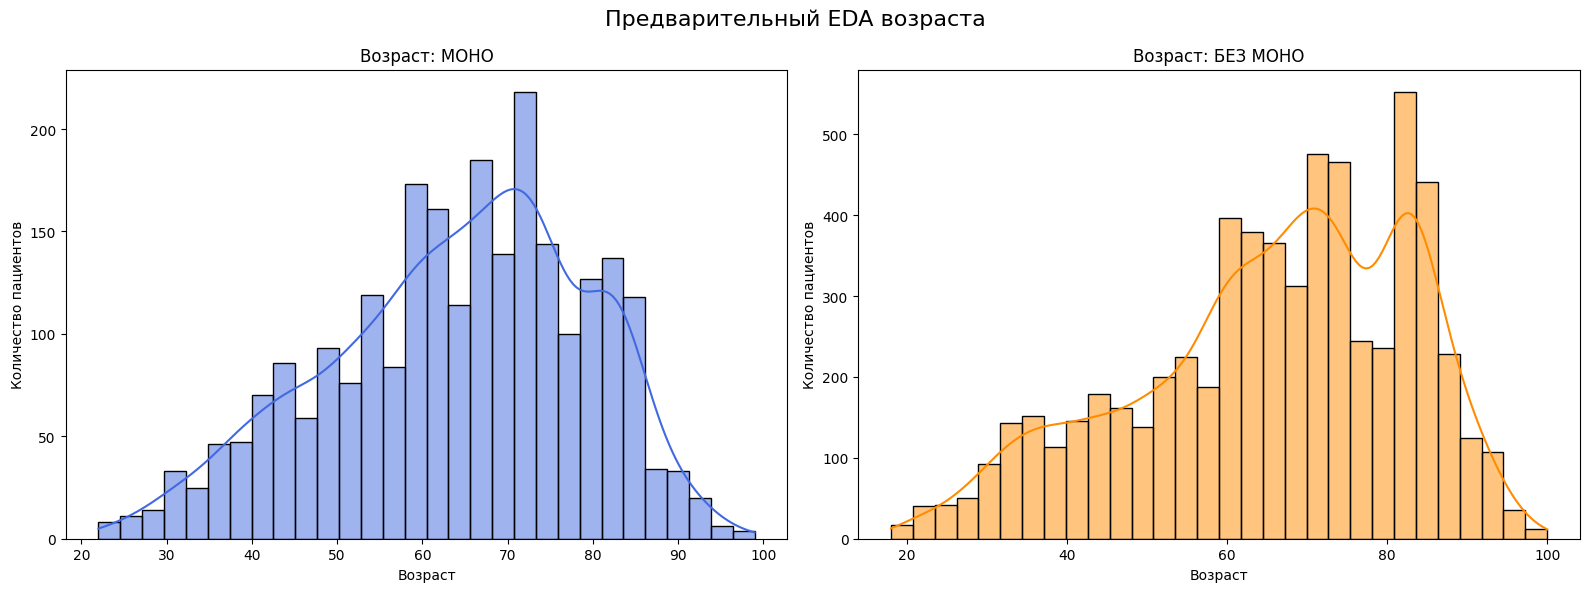

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Предварительный EDA возраста', fontsize=16)

sns.histplot(data=df_mono, x='Age', bins=30, kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('Возраст: МОНО')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество пациентов')

sns.histplot(data=df_nomono, x='Age', bins=30, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Возраст: БЕЗ МОНО')
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Количество пациентов')

plt.tight_layout()
plt.show()

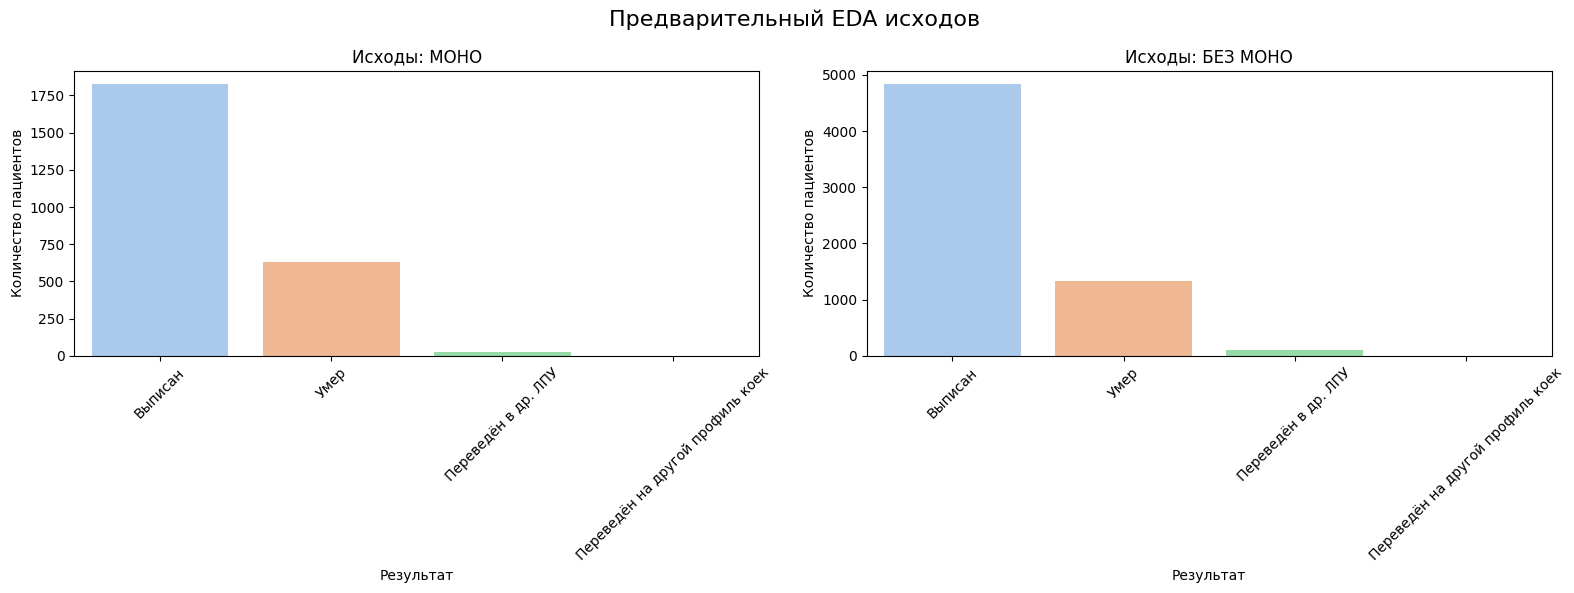

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Предварительный EDA исходов', fontsize=16)

sns.countplot(data=df_mono, x='Outcome', palette='pastel', ax=axes[0])
axes[0].set_title('Исходы: MОНО')
axes[0].set_xlabel('Результат')
axes[0].set_ylabel('Количество пациентов')
axes[0].tick_params(axis='x', rotation=45) 

sns.countplot(data=df_nomono, x='Outcome', palette='pastel', ax=axes[1])
axes[1].set_title('Исходы: БЕЗ МОНО')
axes[1].set_xlabel('Результат')
axes[1].set_ylabel('Количество пациентов')
axes[1].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

In [22]:
print(df_D.info())
total_rows = len(df_D)
unique_ids = df_D['CaseID'].nunique()
print(f"\nВсего строк: {total_rows}")
print(f"Уникальных пациентов: {unique_ids}")
print(f"Дубликатов: {total_rows - unique_ids}")

<class 'pandas.DataFrame'>
RangeIndex: 10541 entries, 0 to 10540
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CaseID       10541 non-null  int64  
 1   Показатель   10541 non-null  str    
 2   Результат_D  10001 non-null  object 
 3   Unnamed: 3   0 non-null      float64
 4   Unnamed: 4   0 non-null      float64
 5   Unnamed: 5   0 non-null      float64
 6   Записей      1 non-null      float64
 7   Уникальных   1 non-null      float64
dtypes: float64(5), int64(1), object(1), str(1)
memory usage: 658.9+ KB
None

Всего строк: 10541
Уникальных пациентов: 9998
Дубликатов: 543


In [23]:
print(df_F.info())
total_rows = len(df_F)
unique_ids = df_F['CaseID'].nunique()
print(f"\nВсего строк: {total_rows}")
print(f"Уникальных пациентов: {unique_ids}")
print(f"Дубликатов: {total_rows - unique_ids}")

<class 'pandas.DataFrame'>
RangeIndex: 10395 entries, 0 to 10394
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Дата результата  10377 non-null  str    
 1   IDS              10395 non-null  int64  
 2   Дата взятия      10395 non-null  str    
 3   CaseID           10395 non-null  int64  
 4   Показатель_F     10395 non-null  str    
 5   Результат        10377 non-null  object 
 6   Unnamed: 6       0 non-null      float64
 7   Unnamed: 7       2 non-null      float64
dtypes: float64(2), int64(2), object(1), str(3)
memory usage: 649.8+ KB
None

Всего строк: 10395
Уникальных пациентов: 10021
Дубликатов: 374


Загрузились пустые колонки, удалим их:

In [24]:
df_D.drop(columns=["Unnamed: 3", "Unnamed: 4", "Unnamed: 5", "Записей", "Уникальных"], inplace=True)


In [25]:
df_F.drop(columns=["Unnamed: 6", "Unnamed: 7"], inplace=True)

Колонки 'Результат_D' и 'Результат_F'имеют тип данных Object, вместо float64. Если детальнее рассмотреть данные, окажется, что в них присутствуют заглушки строкового типа


In [26]:
#находим все строки, которые не могут стать числами, и смотрим их уникальные исходные значения

bad_values = df_D[pd.to_numeric(df_D['Результат_D'], errors='coerce').isna()]['Результат_D'].unique()

print("Все текстовые аномалии в датасете:")
print(bad_values)

Все текстовые аномалии в датасете:
['>3000' nan '>3000.0' '>' 'перебрать' 'наруш-е соотношения' 'сгусток!!!'
 '10,94,84' 'более 3000' 'наруш.соотношения' 'сгусток' 'нет пробирки'
 'перезабор.мало крови' '192...97' 'наруш. соотношения'
 'нарушен-е соотношения']


In [27]:
bad_values1 = df_F[pd.to_numeric(df_F['Результат'], errors='coerce').isna()]['Результат'].unique()

print("Все текстовые аномалии в датасете:")
print(bad_values1)

Все текстовые аномалии в датасете:
[nan 'нет пробирки' '283,8227,9' 'перебрать']


In [28]:
df_D['Результат_D_чистый'] = df_D['Результат_D'].astype(str).str.replace(',', '.', regex=False)

df_D['Результат_D_чистый'] = pd.to_numeric(df_D['Результат_D_чистый'], errors='coerce')


In [29]:
df_F['Результат_F_чистый'] = df_F['Результат'].astype(str).str.replace(',', '.', regex=False)

df_F['Результат_F_чистый'] = pd.to_numeric(df_F['Результат_F_чистый'], errors='coerce')

In [30]:
na_ratio = df_D['Результат_D_чистый'].isna().sum() / df_D['Результат_D'].count()
print(f"Процентное соотношение заглушек результата: {(na_ratio * 100):.1f}%")


Процентное соотношение заглушек результата: 16.5%


In [31]:
na_ratio1 = df_F['Результат_F_чистый'].isna().sum() / df_F['Результат'].count()
print(f"Процентное соотношение заглушек результата: {(na_ratio1 * 100):.1f}%")

Процентное соотношение заглушек результата: 0.2%


## 1.4 Preprocessing

In [32]:
df_mono1 = df_mono.copy()
df_nomono1 = df_nomono.copy()

In [33]:
df_nomono["CaseID"].isna().sum()

np.int64(660)

In [34]:
# 1находим макс ID по всем таблицам
max_mono = pd.to_numeric(df_mono['CaseID'], errors='coerce').max()
max_nomono = pd.to_numeric(df_nomono['CaseID'], errors='coerce').max()
max_D = pd.to_numeric(df_D['CaseID'], errors='coerce').max()
max_F = pd.to_numeric(df_F['CaseID'], errors='coerce').max()

# определяем стартовую точку
start_id = int(max([max_mono, max_nomono, max_D, max_F])) + 1

# сколько пропусков нужно заполнить
ids_to_fill_mono = df_mono['CaseID'].isna().sum()
ids_to_fill_nomono = df_nomono['CaseID'].isna().sum()

mono_ints = list(range(start_id, start_id + ids_to_fill_mono))
nomono_ints = list(range(start_id + ids_to_fill_mono, start_id + ids_to_fill_mono + ids_to_fill_nomono))

# заполняем пропуски в таблицах
df_mono.loc[df_mono['CaseID'].isna(), 'CaseID'] = mono_ints
df_nomono.loc[df_nomono['CaseID'].isna(), 'CaseID'] = nomono_ints

# приводим к типу int
df_mono['CaseID'] = df_mono['CaseID'].astype(int)
df_nomono['CaseID'] = df_nomono['CaseID'].astype(int)

print(f"Нумерация новых пациентов успешно началась с числа: {start_id}")

Нумерация новых пациентов успешно началась с числа: 390078


In [35]:
# сортируем по дате выписки
df_mono = df_mono.sort_values(by='End', ascending=True)
df_nomono = df_nomono.sort_values(by='End', ascending=True)

df_mono_unique = df_mono.drop_duplicates(subset=['CaseID'], keep='last')
df_nomono_unique = df_nomono.drop_duplicates(subset=['CaseID'], keep='last')

print("Отчет по дубликатам:")
print(f"В базе МОНО было {len(df_mono)} строк, осталось {len(df_mono_unique)}.")
print(f"Удалено повторных госпитализаций: {len(df_mono) - len(df_mono_unique)}\n")

print(f"В базе БЕЗ МОНО было {len(df_nomono)} строк, осталось {len(df_nomono_unique)}.")
print(f"Удалено повторных госпитализаций: {len(df_nomono) - len(df_nomono_unique)}")

Отчет по дубликатам:
В базе МОНО было 2484 строк, осталось 2481.
Удалено повторных госпитализаций: 3

В базе БЕЗ МОНО было 6262 строк, осталось 6153.
Удалено повторных госпитализаций: 109


In [36]:
df_D_clean = df_D[['CaseID', 'Результат_D_чистый']].copy()
df_F_clean = df_F[['CaseID', 'Результат_F_чистый']].copy()
 
df_mono_merged = (df_mono_unique
                  .merge(df_D_clean, on='CaseID', how='left')
                  .merge(df_F_clean, on='CaseID', how='left'))
 
df_nomono_merged = (df_nomono_unique
                    .merge(df_D_clean, on='CaseID', how='left')
                    .merge(df_F_clean, on='CaseID', how='left'))
 
print("После merge:")
print(f"МОНО:    {df_mono_merged.shape}")
print(f"БЕЗ МОНО: {df_nomono_merged.shape}")

После merge:
МОНО:    (2790, 10)
БЕЗ МОНО: (6965, 10)


In [37]:
for name, df in [("МОНО", df_mono_merged), ("БЕЗ МОНО", df_nomono_merged)]:
    print(f"{name}:")
    print(df[['Результат_D_чистый', 'Результат_F_чистый']].isna().mean().mul(100).round(1).to_string() + " %")

МОНО:
Результат_D_чистый    13.2
Результат_F_чистый     5.1 %
БЕЗ МОНО:
Результат_D_чистый    22.2
Результат_F_чистый    10.1 %


In [38]:
df_mono_known   = df_mono_merged[df_mono_merged['Outcome'].isin(['Умер', 'Выписан'])].copy()
df_nomono_known = df_nomono_merged[df_nomono_merged['Outcome'].isin(['Умер', 'Выписан'])].copy()

df_mono_known['dead']   = (df_mono_known['Outcome']   == 'Умер').astype(int)
df_nomono_known['dead'] = (df_nomono_known['Outcome'] == 'Умер').astype(int)

df_mono_known['group']   = 'МОНО'
df_nomono_known['group'] = 'БЕЗ МОНО'
df_all = pd.concat([df_mono_known, df_nomono_known], ignore_index=True)

print(f"БД МОНО:     {len(df_mono_known)} из {len(df_mono_merged)}")
print(f"БД БЕЗ МОНО: {len(df_nomono_known)} из {len(df_nomono_merged)}")
print(f"Итого:    {len(df_all)}")

БД МОНО:     2754 из 2790
БД БЕЗ МОНО: 6827 из 6965
Итого:    9581


In [39]:
df_mono_known.to_excel('../data/df_mono_known.xlsx', index=False)
df_nomono_known.to_excel('../data/df_nomono_known.xlsx', index=False)
df_all.to_excel('../data/df_all.xlsx', index=False)